In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/PhD/MatrixProductBP.jl/results_for_article`


In [2]:
using JLD2, Plots, Statistics, LaTeXStrings, MatrixProductBP, Tullio, LinearAlgebra
using UnPack: @unpack
blue = palette(:tab10)[1]
orange = palette(:tab10)[2]
green = palette(:tab10)[3]
red = palette(:tab10)[4]
brown = "#b75e00"
beige = "#efe7dd"
beige2 = "#f2f1ec"
cyan = "#289dd2"
;

## Random tree (preferential attachment) with random couplings

In [3]:
N = 100
D = load("./tree_$(N)_beta0,5_h0_randomJ_conv.jld2")
m_fourier = D["m_fourier"]
energy_fourier = D["energy_fourier"]
J = D["J"]

nsamp = [10^6]
m_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_tree_$(N)_randomJ_beta0,5_h0_nsamp$(n)_conv.jld2")
    push!(m_mc, D["m_mc"])
    push!(energy_mc, D["energy_mc"])
end

col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
T = length(m_fourier[1][1]) - 1
;

er[4, end] = 0.0033187126782075888


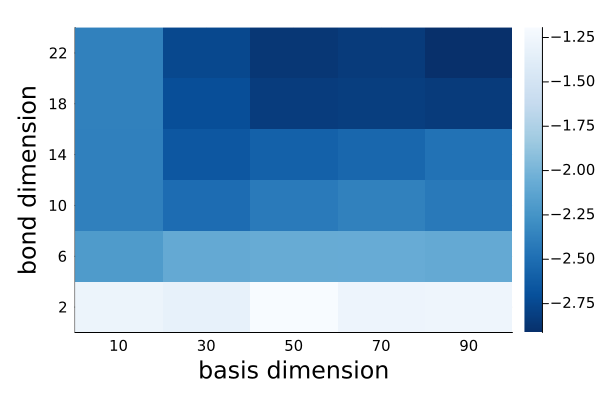

In [4]:
er = zeros(size(m_fourier))

for dK in eachindex(m_fourier)
    er_ = (m_fourier[dK] .- m_mc[end])
    # er_abs = maximum(maximum(abs, e) for e in er_)
    er_sq = sum(sum(e.^2) for e in er_) / (N*(T+1)) |> sqrt
    er[dK] = er_sq
end

@show er[4,end]

bondsizes = 2:4:22
basesizes = 10:20:90

pltreeconv = heatmap(collect(basesizes), collect(bondsizes), log10.(er[eachindex(bondsizes),eachindex(basesizes)]),
    c=cgrad(:Blues, rev=true),
    # xscale=:log2,
    # cscale=:log10,
    xlabel="basis dimension",
    ylabel="bond dimension",
    xlabelfontsize=16,
    ylabelfontsize=16,
    legendfontsize=12,
    tickfontsize=10,
    size=(600,400),
    margin=5Plots.mm,
    xticks=(basesizes, string.(basesizes)),
    yticks=(bondsizes, string.(bondsizes))
)

In [5]:
N = 100
D = load("./tree_$(N)_beta0,5_h0_randomJ.jld2")
m_fourier = D["m_fourier"]
energy_fourier = D["energy_fourier"]
J = D["J"]

nsamp = [10^6]
m_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_tree_$(N)_randomJ_beta0,5_h0_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(energy_mc, D["energy_mc"])
end

col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
T = length(m_fourier[1][1]) - 1
;

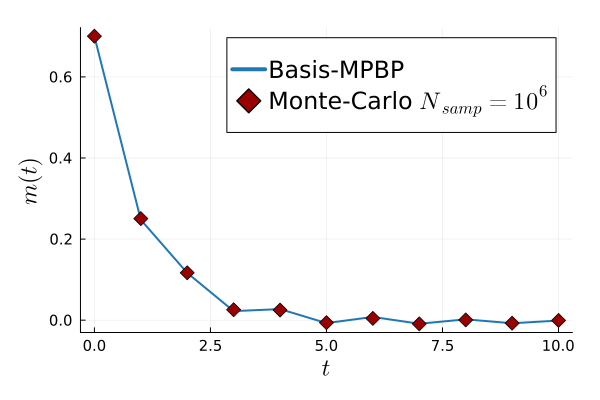

In [6]:
i = 1
y_mc = m_mc[end][i]
y_fourier = m_fourier[i]

T = length(y_fourier) - 1
pltree = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"m(t)")

plot!(pltree, 0:T, y_fourier[1:end], color=blue, lw=2, label="Basis-MPBP")
logmc = Int(log10(nsamp[end]))
plot!(pltree, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")

er_sq = 0.003288057569413181


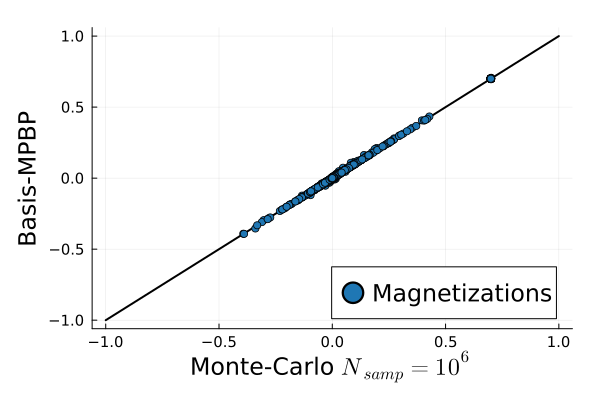

In [7]:
y_fourier_sc = reduce(vcat, y for y in m_fourier)
y_mc_sc = reduce(vcat, y for y in m_mc[end])

er_ = (y_fourier_sc .- y_mc_sc)
# er_abs = maximum(maximum(abs, e) for e in er_)
er_sq = sum(sum(e.^2) for e in er_) / (N*(T+1)) |> sqrt
@show er_sq

pl2tree = plot(legend=:bottomright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel="Monte-Carlo "*L"N_{samp}=10^{%$logmc}",
            ylabel="Basis-MPBP")

plot!(pl2tree, -1.0:0.1:1.0, -1.0:0.1:1.0, label="", c=:black, lw=2)
plot!(pl2tree, y_mc_sc, y_fourier_sc, st=:scatter, markerstrokecolor=:black, color=blue, label="Magnetizations")

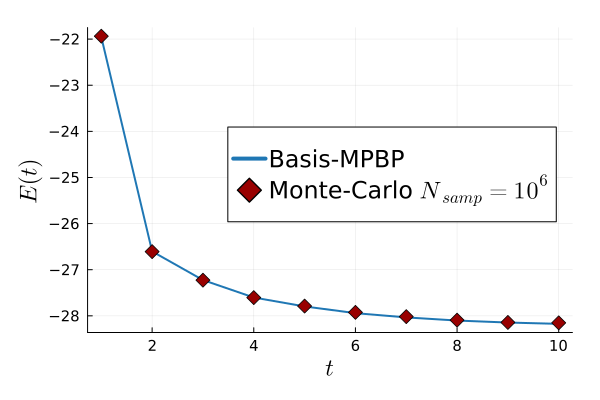

In [8]:
E_fourier = sum(energy_fourier[i,j,:] for i=1:N, j=1:N)

pl3tree = plot(legend=:bottomright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t", 
            ylabel=L"E(t)")

plot!(pl3tree, -E_fourier; label="Basis-MPBP", legend=:right, lw=2, color=blue)#, ylims=(0,1))

for (k,n) in enumerate(nsamp)
    logmc = Int(log10(n))
    plot!(pl3tree, -energy_mc[k]; label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}", st=:scatter, marker=:diamond, markersize=7, color=col[k])
end

plot!()

In [9]:
# savefig(pltree, "figures/tree_magnetization_single_node.pdf")
# savefig(pl2tree, "figures/tree_magnetization_scatter.pdf")
# savefig(pl3tree, "figures/tree_energy.pdf")

## Configuration model (power law) with random couplings

In [10]:
N = 200

D = load("./configuration_$(N)_0,6_beta0,7_h0_randomJ.jld2")
m_fourier = D["m_fourier"]
energy_fourier = D["energy_fourier"]
J = D["J"]

nsamp = [10^6]
m_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_configuration_$(N)_0,6_randomJ_beta0,7_h0_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(energy_mc, D["energy_mc"])
end

T = length(m_fourier) - 1
logmc = Int(log10(nsamp[end]))
col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
;

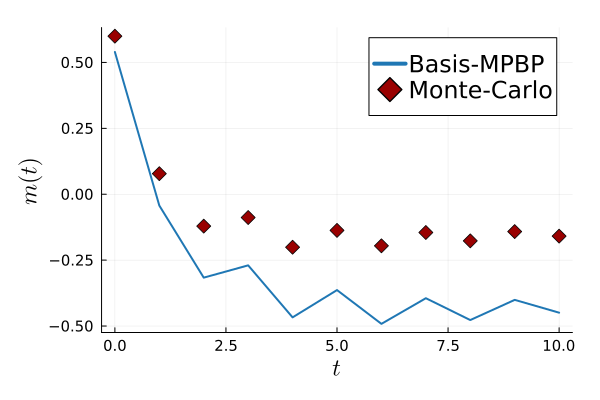

In [11]:
i = 8
y_mc = m_mc[end][i]
# err_mc = σ_mc[i]
y_fourier = m_fourier[i]

T = length(y_fourier) - 1
plconf = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"m(t)")

plot!(plconf, 0:T, y_fourier[1:end], color=blue, lw=2, label="Basis-MPBP")
plot!(plconf, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo")

er_sq = 0.019884111379943805


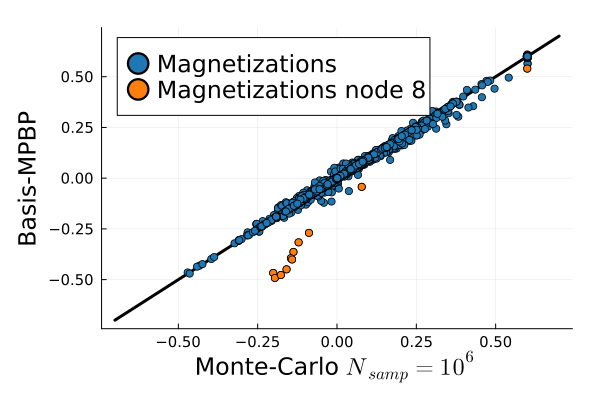

In [12]:
y_fourier_sc = reduce(vcat, y for y in m_fourier)
y_mc_sc = reduce(vcat, y for y in m_mc[end])

er_ = (y_fourier_sc .- y_mc_sc)
# er_abs = maximum(maximum(abs, e) for e in er_)
er_sq = sum(sum(e.^2) for e in er_) / (N*(T+1)) |> sqrt
@show er_sq

pl2conf = plot(legend=:topleft, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel="Monte-Carlo "*L"N_{samp}=10^{%$logmc}",
            ylabel="Basis-MPBP")

colors = fill(blue, length(y_mc_sc))
node = 8
highlight = (node-1)*11+1:(node)*11
colors[highlight] .= orange

plot!(pl2conf, -0.7:0.1:0.7, -0.7:0.1:0.7, label="", c=:black, lw=3)
plot!(pl2conf, y_mc_sc, y_fourier_sc, st=:scatter, markerstrokecolor=:black, color=colors, label="Magnetizations")
plot!(pl2conf, y_mc_sc[highlight], y_fourier_sc[highlight], st=:scatter, markerstrokecolor=:black, color=orange, label="Magnetizations node $node")

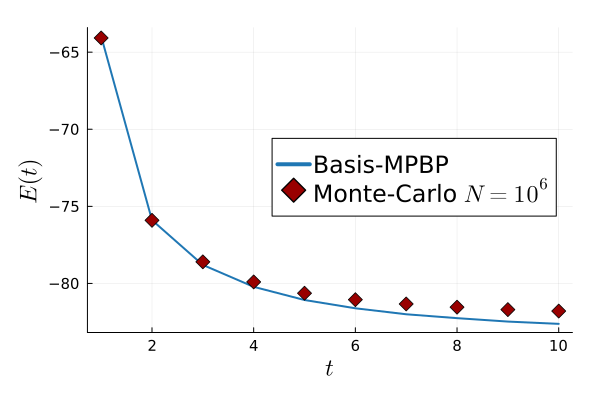

In [13]:
E_fourier = sum(energy_fourier[i,j,:] for i=1:N, j=1:N)
E_mc = []
for en_mc in energy_mc
    push!(E_mc, en_mc)
end

pl3conf = plot(legend=:bottomright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t", 
            ylabel=L"E(t)")

plot!(pl3conf, -E_fourier; label="Basis-MPBP", legend=:right, lw=2, color=blue)#, ylims=(0,1))

for (k,N) in enumerate(nsamp)
    logmc = Int(log10(N))
    plot!(pl3conf, -energy_mc[k]; label="Monte-Carlo "*L"N=10^{%$logmc}", st=:scatter, marker=:diamond, markersize=7, color=col[k])
end

plot!()

In [14]:
# savefig(plconf, "figures/conf_magnetization_single_node.pdf")
# savefig(pl2conf, "figures/conf_magnetization_scatter.pdf")
# savefig(pl3conf, "figures/conf_energy.pdf")

## Infinite regular graph with random couplings

In [15]:
D = load("./infinite_8-reg_beta0,3_dmax15_K60.jld2")

beliefs = D["bs"]
beliefs2times = D["bs2times"]
beliefs2vars = D["bs2vars"]


Nmc = 5*10^3
nsamp = [10^4, 10^5, 10^6]
m_mc = []
autocorr_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_infinite_8-reg_beta0,3_Nmc$(Nmc)_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(autocorr_mc, D["autocorr_mc"])
    push!(energy_mc, D["energy_mc"])
end

T = length(beliefs[1]) - 1
col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
;

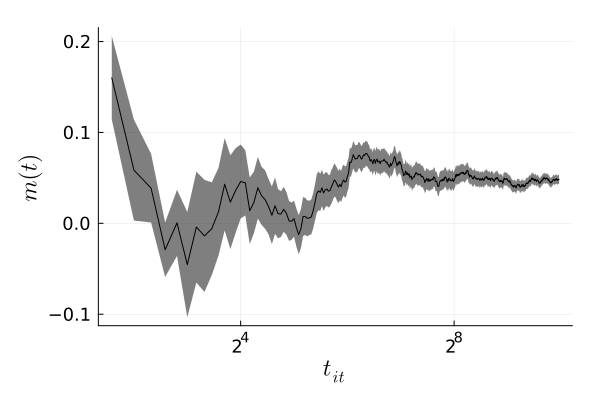

In [16]:
import MatrixProductBP.Models: potts2spin

tmag = 3
ws = 200
tistart = 3
beliefs_ = beliefs[701:end]

v = Float64[]
vabs = Float64[]
vstd = Float64[]
for ti in tistart:length(beliefs_)
    range = ti÷2+1:ti

    mags = [expectation.(potts2spin, b) for b in beliefs_[range]]
    mag = mean(m[tmag] for m in mags)
    magabs = mean(abs, (m[tmag] for m in mags))
    stdmag = std(m[tmag] for m in mags) / sqrt(length(mags))
    push!(v, mag)
    push!(vabs, magabs)
    push!(vstd, stdmag)
end

plrrconv = plot(legend=false, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=10,
            tickfontsize=12,
            size=(600,400),
            xlabel=L"t_{it}", 
            ylabel=L"m(t)")

plot!(plrrconv, tistart:length(beliefs_), v, ribbon=vstd, xscale=:log2, color=:black)
# plot!(tistart:length(beliefs_), m_mc[end][tmag]*ones(length(beliefs_)-tistart+1))

In [17]:
import MatrixProductBP.Models: potts2spin
ns = 500
range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
ms = [expectation.(potts2spin, b) for b in beliefs[range]]
m_fourier = mean(ms)
σ_fourier = std(ms) ./ sqrt(length(ms))

rs = [expectation.(potts2spin, btu) for btu in beliefs2times[range]]
cs = MatrixProductBP.covariance.(rs, ms)
c_avg = mean(abs.(x) for x in cs)
c_std = std(cs) ./ sqrt(length(cs))

degree = 4
ns2vars = ns * degree
range = length(beliefs2vars)+1-min(ns2vars, length(beliefs2vars)):length(beliefs2vars)
c2s = []

function p2(X)
    @tullio _[xᵢᵗ⁺¹, xⱼᵗ] := X[xᵢᵗ,xⱼᵗ,xᵢᵗ⁺¹,xⱼᵗ⁺¹]
end
for b2v in @view beliefs2vars[range]
    Jⱼᵢ = b2v[2]
    X = b2v[1]
    push!(c2s, Jⱼᵢ.*[expectation(potts2spin, p2(x)) for x in X])
end
c2_avg = mean(c2s)
c2_std = std(c2s) ./ sqrt(length(c2s))
;

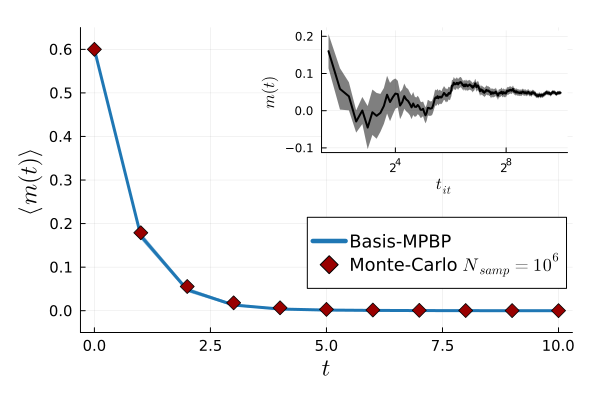

In [18]:
y_mc = m_mc[end]
y_fourier = m_fourier

T = length(y_fourier) - 1
plrr = plot(legend=(0.55,0.3), margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle m(t) \rangle",
            ylim=(-0.05, 0.65))

plot!(plrr, 0:T, y_fourier[1:end], color=blue, ribbon=σ_fourier, lw=3, label="Basis-MPBP")
logmc = Int(log10(nsamp[end]))
plot!(plrr, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
plot!(tistart:length(beliefs_), v, ribbon=vstd, xscale=:log2, color=:black, legend=false, lw=2, xlabel=L"t_{it}", ylabel=L"m(t)",
    inset=(1, bbox(0.49, 0.01, 0.5, 0.4)), subplot=2)

display(plrr)

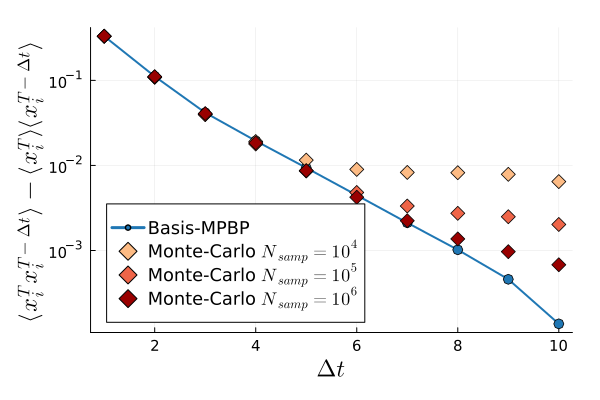

In [19]:
pl2rr = plot(legend=:bottomleft, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"\Delta t",
            ylabel=L"\langle x_{i}^T x_{i}^{T-\Delta t}\rangle-" * 
            L"\langle x_{i}^T\rangle\langle x_{i}^{T-\Delta t}\rangle", 
            yaxis=:log)

plot!(pl2rr, T:-1:1, c_avg[1:1:10,11]; skip_even=true, m=:o, us=4:2:T, label="Basis-MPBP", color=blue, lw=2, markersize=5)

for (k,N) in enumerate(nsamp)
    logmc = Int(log10(N))
    plot!(T:-1:1, autocorr_mc[k][1:1:end-1], st=:scatter, marker=:diamond, color=col[k], markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
end

display(pl2rr)

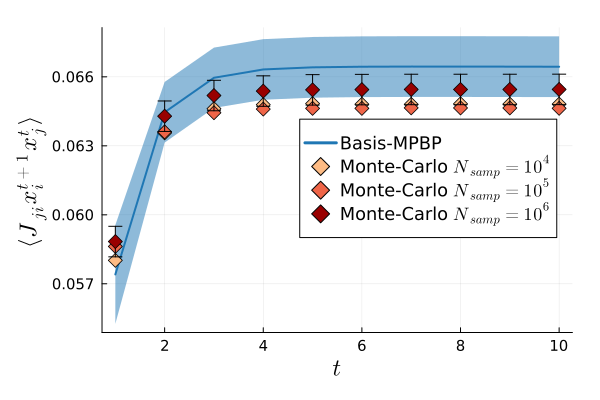

In [20]:
pl3rr = plot(legend=:right, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle J_{ji} x_i^{t+1} x_j^t \rangle")

plot!(pl3rr, c2_avg, ribbon=c2_std; label="Basis-MPBP", color=blue, lw=2)#, ylims=(0,1))

for (k,N) in enumerate(nsamp[1:end-1])
    logmc = Int(log10(N))
    plot!(pl3rr, energy_mc[k]; label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}", st=:scatter, marker=:diamond, markersize=7, color=col[k])
end
plot!(pl3rr, energy_mc[3], yerr=((2/3) .- energy_mc[3].^2)./10^3; label="Monte-Carlo "*L"N_{samp}=10^{6}", st=:scatter, marker=:diamond, markersize=7, color=col[3])

display(pl3rr)

In [21]:
# savefig(plrr, "figures/rr_magnetization_single_node.pdf")
# savefig(pl2rr, "figures/rr_autocorrelation.pdf")
# savefig(pl3rr, "figures/rr_energy.pdf")

## Infinite Erdős-Rényi graph with random couplings

In [22]:
D = load("./infinite_er_beta0,5_dmax15_K60.jld2")

beliefs = D["bs"]
beliefs2times = D["bs2times"]
beliefs2vars = D["bs2vars"]


Nmc = 5*10^3
nsamp = [10^4, 10^5, 10^6]
# nsamp = [10^4, 10^5, 10^6]
m_mc = []
autocorr_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_infinite_er_beta0,5_Nmc$(Nmc)_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(autocorr_mc, D["autocorr_mc"])
    push!(energy_mc, D["energy_mc"])
end

T = length(beliefs[1]) - 1
col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
;

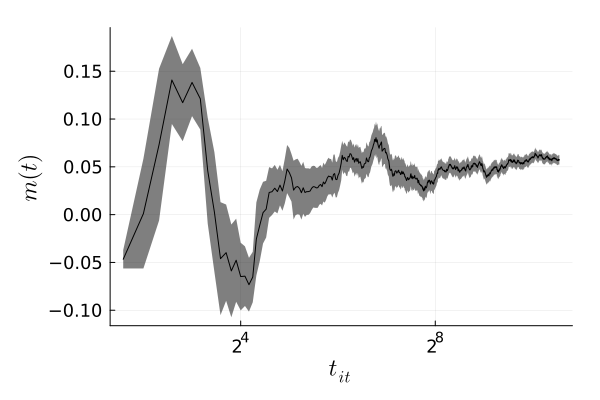

In [23]:
import MatrixProductBP.Models: potts2spin

tmag = 3
ws = 200
tistart = 3
beliefs_ = beliefs[701:end]

v = Float64[]
vabs = Float64[]
vstd = Float64[]
for ti in tistart:length(beliefs_)
    range = ti÷2+1:ti

    mags = [expectation.(potts2spin, b) for b in beliefs_[range]]
    mag = mean(m[tmag] for m in mags)
    magabs = mean(abs, (m[tmag] for m in mags))
    stdmag = std(m[tmag] for m in mags) / sqrt(length(mags))
    push!(v, mag)
    push!(vabs, magabs)
    push!(vstd, stdmag)
end

plrrconv = plot(legend=false, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=10,
            tickfontsize=12,
            size=(600,400),
            xlabel=L"t_{it}", 
            ylabel=L"m(t)")

plot!(plrrconv, tistart:length(beliefs_), v, ribbon=vstd, xscale=:log2, color=:black)
# plot!(tistart:length(beliefs_), m_mc[end][tmag]*ones(length(beliefs_)-tistart+1))

In [24]:
import MatrixProductBP.Models: potts2spin
ns = 500
range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
ms = [expectation.(potts2spin, b) for b in beliefs[range]]
m_fourier = mean(ms)
σ_fourier = std(ms) ./ sqrt(length(ms))

rs = [expectation.(potts2spin, btu) for btu in beliefs2times[range]]
cs = MatrixProductBP.covariance.(rs, ms)
c_avg = mean(abs.(x) for x in cs)
c_std = std(cs) ./ sqrt(length(cs))

degree = 4
ns2vars = ns * degree
range = length(beliefs2vars)+1-min(ns2vars, length(beliefs2vars)):length(beliefs2vars)
c2s = []

function p2(X)
    @tullio _[xᵢᵗ⁺¹, xⱼᵗ] := X[xᵢᵗ,xⱼᵗ,xᵢᵗ⁺¹,xⱼᵗ⁺¹]
end
for b2v in @view beliefs2vars[range]
    Jⱼᵢ = b2v[2]
    X = b2v[1]
    push!(c2s, Jⱼᵢ.*[expectation(potts2spin, p2(x)) for x in X])
end
c2_avg = mean(c2s)
c2_std = std(c2s) ./ sqrt(length(c2s))
;

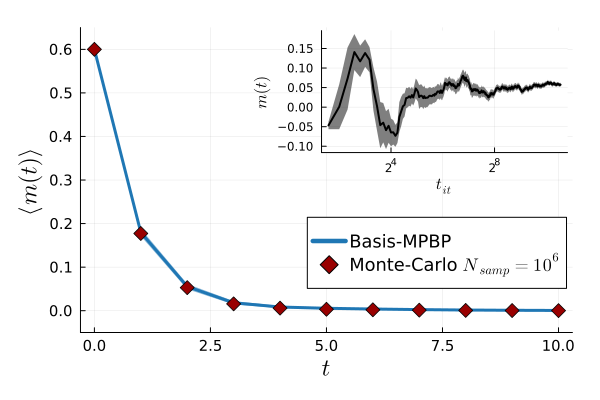

In [25]:
y_mc = m_mc[end]
y_fourier = m_fourier

T = length(y_fourier) - 1
pler = plot(legend=(0.55,0.3), margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle m(t) \rangle",
            ylim=(-0.05, 0.65))

plot!(pler, 0:T, y_fourier[1:end], color=blue, ribbon=σ_fourier, lw=3, label="Basis-MPBP")
logmc = Int(log10(nsamp[end]))
plot!(pler, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
plot!(tistart:length(beliefs_), v, ribbon=vstd, xscale=:log2, color=:black, legend=false, lw=2, xlabel=L"t_{it}", ylabel=L"m(t)",
    inset=(1, bbox(0.49, 0.01, 0.5, 0.4)), subplot=2)

display(pler)

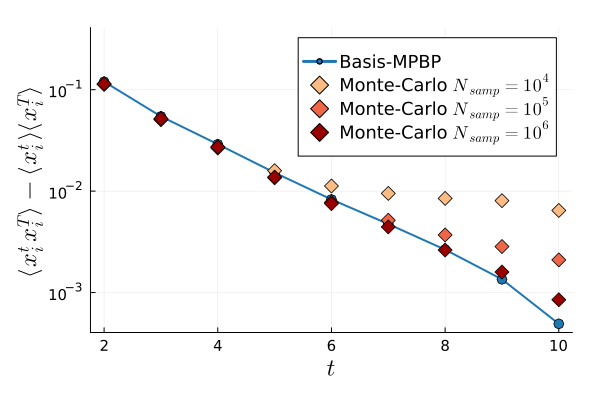

In [26]:
pl2er = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle x_{i}^t x_{i}^{T}\rangle-" * 
            L"\langle x_{i}^t\rangle\langle x_{i}^{T}\rangle", 
            yaxis=:log)

plot!(pl2er, T:-1:2, c_avg[1:1:9,11]; skip_even=true, m=:o, us=4:2:T, label="Basis-MPBP", color=blue, lw=2, markersize=5)
for (k,N) in enumerate(nsamp)
    logmc = Int(log10(N))
    plot!(T:-1:2, autocorr_mc[k][1:1:end-1], st=:scatter, marker=:diamond, color=col[k], markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
end

display(pl2er)

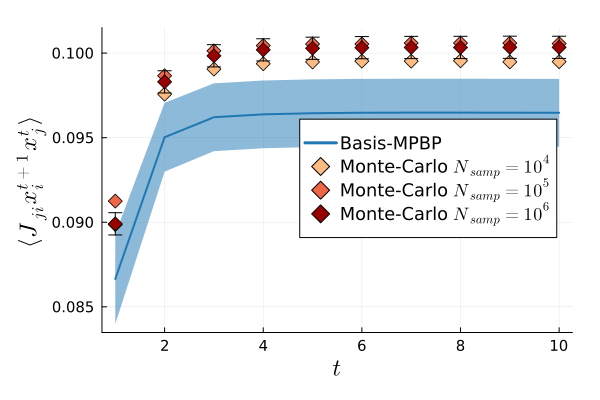

In [27]:
pl3er = plot(legend=:right, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle J_{ji} x_i^{t+1} x_j^t \rangle")

plot!(pl3er, c2_avg, ribbon=c2_std; label="Basis-MPBP", color=blue, lw=2)#, ylims=(0,1))

for (k,N) in enumerate(nsamp[1:end-1])
    logmc = Int(log10(N))
    plot!(pl3er, energy_mc[k]; label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}", st=:scatter, marker=:diamond, markersize=7, color=col[k])
end
plot!(pl3er, energy_mc[3], yerr=((2/3) .- energy_mc[3].^2)./10^3; label="Monte-Carlo "*L"N_{samp}=10^{6}", st=:scatter, marker=:diamond, markersize=7, color=col[3])


display(pl3er)

In [28]:
# savefig(pler, "figures/er_magnetization_single_node.pdf")
# savefig(pl2er, "figures/er_autocorrelation.pdf")
# savefig(pl3er, "figures/er_energy.pdf")

## Large deviations (reweighting at final time)

In [29]:
D = load("./infinite_8-reg_reweight_h3_dmax10_K30.jld2")

beliefs = D["bs"]
free_energies = D["fs"]

T = length(beliefs[1]) - 1
;

In [30]:
import MatrixProductBP.Models: potts2spin
ns = 2000
range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
ms = [expectation.(potts2spin, b) for b in beliefs[range]]
m_fourier = mean(ms)
σ_fourier = std(ms) ./ sqrt(length(ms))
;

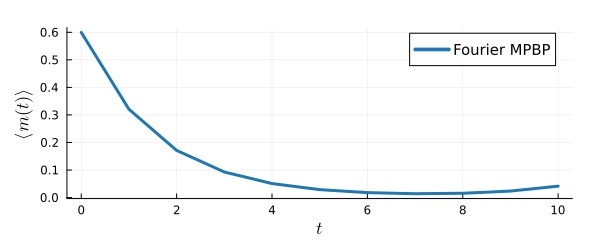

In [31]:
y_fourier = m_fourier

T = length(y_fourier) - 1
plld = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=12,
            ylabelfontsize=12,
            legendfontsize=10,
            tickfontsize=8,
            size=(600,250),
            xlabel=L"t",
            ylabel=L"\langle m(t) \rangle",
            xticks=0:2:T)
            # ylim=(-0.2, 0.3))

plot!(plld, 0:T, y_fourier[1:end], color=blue, ribbon=σ_fourier, lw=3, label="Fourier MPBP")

display(plld)

In [32]:
import MatrixProductBP.Models: potts2spin

bs = []
fs = []
ms = []

for cnt in -24:3:24
    D = load("./infinite_8-reg_reweight_h$(cnt)_dmax10_K30.jld2")
    beliefs = D["bs"]
    free_energies = D["fs"]
    push!(bs, D["bs"])

    ns = 4000
    range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
    mag = [expectation.(potts2spin, b) for b in beliefs[range]]
    range_f = length(free_energies)+1-min(ns, length(free_energies)):length(free_energies)
    f = mean(free_energies[range_f])
    push!(ms, mean(mag))
    push!(fs, f)
end

hs = -0.24:0.03:0.24 |> collect
msend = [m[end] for m in ms]
;

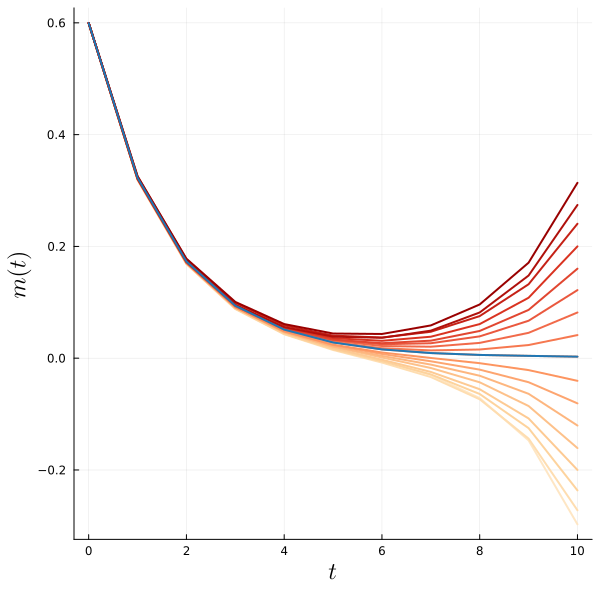

In [33]:
col = cgrad(:OrRd_7, length(hs)+1, categorical=true)[2:end]

pl1ld = plot(xlabel="t", ylabel="m(t)", lw=2, legend=false)
pl1ld = plot(legend=false, margin=0Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=10,
            tickfontsize=8,
            size=(600,600),
            xlabel=L"t",
            ylabel=L"m(t)",
            xticks=0:2:T)
            # ylim=(-0.2, 0.3))

for (k,h) in enumerate(hs)
    plot!(pl1ld, 0:T, ms[k], color=col[k], lw=2)
end
plot!(pl1ld, 0:T, ms[9], color=blue, lw=2)

display(pl1ld)

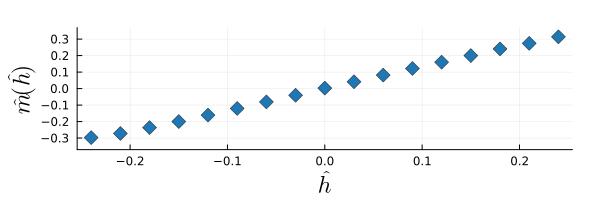

In [34]:
pl2ld = plot(hs, msend, 
            xlabel=L"\hat h", 
            ylabel=L"\hat m(\hat h)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=blue, 
            lw=2, 
            legend=false,
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.37,0.37),
            size=(600,200),
            margin=5Plots.mm)

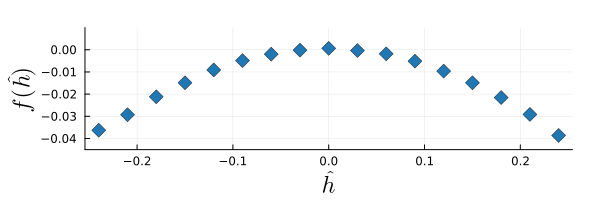

In [35]:
pl3ld = plot(hs, float.(fs), 
            xlabel=L"\hat h", 
            ylabel=L"f(\hat h)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=blue, 
            lw=2, 
            legend=false, 
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.045,0.01),
            size=(600,200),
            margin=5Plots.mm)

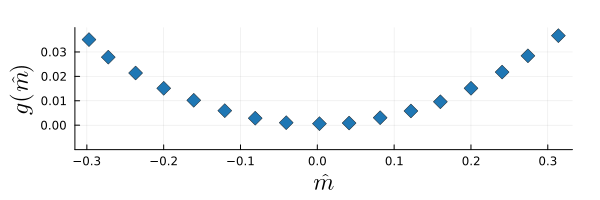

In [36]:
gs = fs .+ hs .* msend
pl4ld = plot(msend, gs, 
            xlabel=L"\hat m", 
            ylabel=L"g(\hat m)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=blue, 
            lw=2, 
            legend=false,
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.01,0.04),
            size=(600,200),
            margin=5Plots.mm)

In [37]:
# savefig(pl1ld, "figures/ld_k8_magnetizations.pdf")
# savefig(pl2ld, "figures/ld_k8_m(h).pdf")
# savefig(pl3ld, "figures/ld_k8_f(h).pdf")
# savefig(pl4ld, "figures/ld_k8_g(m).pdf")

## Convergence check (small tree)

In [38]:
N = 10
D = load("./tree_small_bp_$(N)_beta0,5_h0_randomJ.jld2")
m_fourier = D["m_fourier"]
J = D["J"]

T = length(m_fourier) - 1
# bondsizes = [1,2,5,10,15,20]
# basesizes = [2,5,10,20,50,100]
# bondsizes = 4:6:22
# basesizes = 10:20:70
bondsizes = 4:6:40
basesizes = [2^i for i in 3:8]
;

In [39]:
D = load("./tree_small_exact_$(N)_beta0,5_h0_randomJ.jld2")
prob_exact = D["prob_exact"]
m_exact = D["m_exact"];

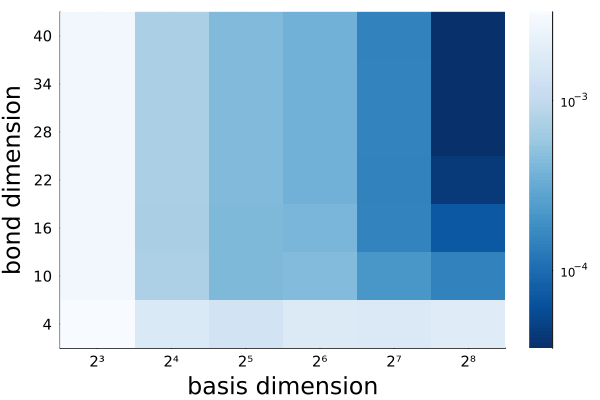

In [40]:
er = zeros(length(bondsizes), length(basesizes))

for d in eachindex(bondsizes), K in eachindex(basesizes)
    m_f = m_fourier[d,K]
    er_ = (m_f .- m_exact)
    # er_abs = maximum(maximum(abs, e) for e in er_)
    er_sq = sum(sum(e.^2) for e in er_) / (N*(T+1)) |> sqrt
    er[d,K] = er_sq
end

function myheatmap(x,y,z; steps = 100, c=cgrad(:Blues, rev=true), kwds...)
    data = heatmap(x, y, log10.(z); colorbar=false, c, kwds...)
    l,u = log10.(extrema(z))
    ra = l:(u-l)/(steps-1):u
    key = heatmap([1], 10 .^(ra), [ra;;]; xaxis=false, ymirror=true, colorbar=false, c, yscale=:log10)
    l = @layout [a{0.95w} b]
    plot(data, key, layout=l)
end


myheatmap(collect(basesizes), collect(bondsizes), er[eachindex(bondsizes),eachindex(basesizes)];
    xscale=:log2,
    c=cgrad(:Blues, rev=true),
    xlabel="basis dimension",
    ylabel="bond dimension",
    xlabelfontsize=16,
    ylabelfontsize=16,
    legendfontsize=12,
    tickfontsize=10,
    xticks=(basesizes, ["2³", "2⁴", "2⁵", "2⁶", "2⁷", "2⁸"]),
    yticks=(bondsizes, string.(bondsizes))
)

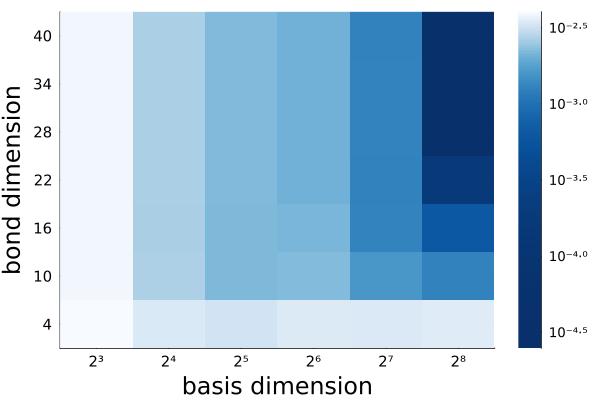

In [41]:
vcolor = -4.6:0.01:-2.4 |> collect
vc = [10.0 .^ vcolor;;]
vlabel = -4.5:0.5:-2.5
# vlabelstr = [L"10^{%$i}" for i in vlabel]

SUPER_MAP = Dict('0'=>'⁰', '1'=>'¹', '2'=>'²', '3'=>'³', '4'=>'⁴', 
                       '5'=>'⁵', '6'=>'⁶', '7'=>'⁷', '8'=>'⁸', '9'=>'⁹', 
                       '-'=>'⁻', '.'=>'⋅')

function to_superscript(val::Real; digits=1)
    str_val = string(round(val, digits=digits))
    return join(get(SUPER_MAP, c, c) for c in str_val)
end

vlabelstr = ["10" * to_superscript(pos; digits=1) for pos in vlabel]

plconvkey = heatmap([1], vcolor, vc,
    colorbar=false,
    xaxis=false,
    ymirror=true,
    c=cgrad(:Blues, rev=true),
    ytickfontsize=9,
    yticks=(vlabel, vlabelstr)
)

plconvdata = heatmap(collect(basesizes), collect(bondsizes), log10.(er[eachindex(bondsizes),eachindex(basesizes)]),
    colorbar=false,
    c=cgrad(:Blues, rev=true),
    xscale=:log2,
    # cscale=:log10,
    xlabel="basis dimension",
    ylabel="bond dimension",
    xlabelfontsize=16,
    ylabelfontsize=16,
    legendfontsize=12,
    tickfontsize=10,
    xticks=(basesizes, ["2³", "2⁴", "2⁵", "2⁶", "2⁷", "2⁸"]),
    yticks=(bondsizes, string.(bondsizes))
)

l = @layout [a{0.95w} b]
plconv = plot(plconvdata, plconvkey, layout=l)#, size=(600,400), margin=5Plots.mm)

In [42]:
# savefig(plconv, "figures/tree_convergence_error.pdf")

## Large deviation check (small tree)

In [43]:
N = 7

Fh = Float64[]
mh = Float64[]
ex_prob = []
ex_Z = Float64[]
for cnt in -5N:5N
    D = load("./tree_small_bp_ld_$(N)_beta0,5_h0_randomJ_$(cnt).jld2")
    free_energies = D["f"]
    magnetizations = D["m_fourier"]
    m = mean(mag[end] for mag in magnetizations)

    # push!(ex_prob, D["ex_pr"])
    # push!(ex_Z, D["ex_Z"])
    push!(Fh, sum(free_energies))
    push!(mh, m)
end

# Fh ./= 2
# Fh = -log.(cosh.(hs))
# Fh = log(2) .- log.(1 .+ cosh.(2*hs))
# Fh .+= 1e-2 .* rand.()

hs_all = 0.0001 .* (-5N:5N) |> collect

hs_i = 1:1:length(hs_all)
hs = hs_all[hs_i]
Fh = Fh[hs_i]
Exphm = [exp(h*m) for h in hs, m in -N:2:N]
Gm = Exphm \ exp.(-Fh.+Fh[(begin + end)÷2])

# gm2 = Fh .+ hs .* mh

8-element Vector{Float64}:
 0.009996981242193982
 0.04941264906444217
 0.1476003592246077
 0.23542464212592382
 0.2588012700445666
 0.19732964049744445
 0.08293447821918361
 0.01849997958163335

er = 0.014822741306674611


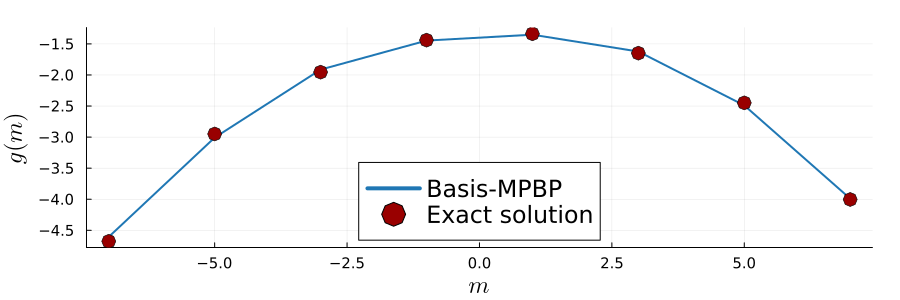

In [44]:
D = load("./tree_small_exact_ld_$(N)_beta0,5_h0_randomJ.jld2")
large_dev_exact = D["large_dev_exact"]
pxT = large_dev_exact[end]

er = sqrt(sum(((log(p_ex) - log(gm))/log(p_ex))^2 for (p_ex, gm) in zip(pxT[-N:2:N], Gm)) / length(Gm))
@show er

col = cgrad(:OrRd_7, 2, categorical=true)[2]

plgm = plot(legend=:bottom, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(900,300),
            xlabel=L"m",
            ylabel=L"g(m)")
            # ylims=(-4.8,-1.2))

plot!(plgm, -N:2:N, log.(Gm), color=blue, lw=2, label="Basis-MPBP")
# plot!(plgm, N.*mh, exp.(gm2), marker=:o, color=orange, lw=2, label="Basis-MPBP saddle")
plot!(plgm, -N:2:N, log.(pxT[-N:2:N]), color=col, st=:scatter, marker=:o, markersize=7, label="Exact solution")

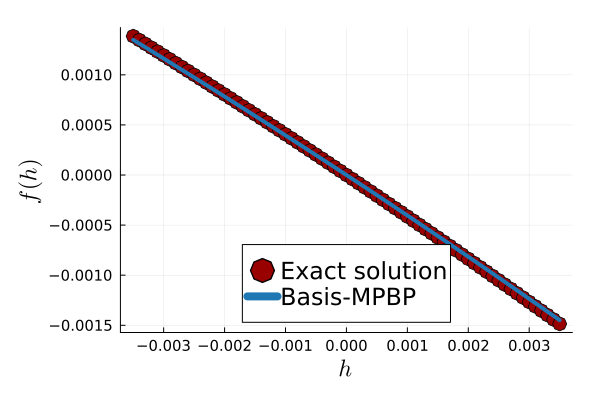

In [45]:
plfh = plot(legend=:bottom, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"h",
            ylabel=L"f(h)")

plot!(plfh, hs, -log.(Exphm*collect(pxT[-N:2:N])), color=col, st=:scatter, marker=:o, markersize=7, label="Exact solution")
plot!(plfh, hs, Fh.-Fh[(begin + end)÷2], color=blue, lw=4, label="Basis-MPBP")

In [46]:
# savefig(plgm, "figures/tree_ld_gm.pdf")
# savefig(plfh, "figures/tree_ld_fh.svg")